# RothermelAndrews2018 and Balbi2020 (mainly RothermelAndrews)

In [24]:
import io, pandas as pd, numpy as np, matplotlib.pyplot as plt
from wildfire_ROS_models.model_set import model_parameters
from wildfire_ROS_models import fuels_database as fd
from wildfire_ROS_models.RothermelAndrews2018 import RothermelAndrews2018

from SALib.sample import saltelli, morris, sobol
from SALib.analyze import sobol as sobol_analyze

import copy

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## Fuel Types


### **CB2005_t7_csv**
- Represents **standard fuel models** used in conservative fire behavior predictions
- Captures **typical weather and fuel conditions**
- Characterized by:
  - Moderate ROS predictions
  - Well-calibrated for **normal grass, shrub, timber, and slash**
- Fuels include:
  - **GR1–GR9** (Grass)
  - **SH1–SH9** (Shrub)
  - **TU1–TU5** (Timber Understory)
  - **TL1–TL8**, TLS, TLO (Timber Litter)
  - **SB1–SB4** (Slash and Blowdown)
- Useful for:
  - Conservative planning and forecasting

---

### **AR2017_table_csv**
- Represents **extreme fire behavior**
- Associated with **explosive shrubland fires**
- Designed for **“worst-case” fuel scenarios**
- Characterized by:
  - Very **high ROS** (Rate of Spread)
  - Very **high SAV** (Surface-Area-to-Volume Ratio)
  - Fuels like **SH5**, **SH7**, **SH9**, and **A4**
- Useful for:
  - Training, planning, and sensitivity analysis for the most severe/extreme inputs

| Fuel Code | Fuel Type         | Description                                                                 |
| --------- | ----------------- | --------------------------------------------------------------------------- |
| GR1–GR9   | Grass             | Fine, continuous grasses; ROS highly sensitive to wind and moisture.        |
| GS1–GS4   | Grass–Shrub Mix   | Mixture of grass and scattered shrubs; carries fire both through and above. |
| SH1–SH9   | Shrub             | Shrublands (e.g. chaparral, sage); ROS depends on height, load, and SAV.    |
| TU1–TU5   | Timber–Understory | Timber stands with understory shrubs or grasses.                            |
| TL1–TL8   | Timber Litter     | Forest litter and woody debris; spread driven by surface fuels.             |
| TLS, TLO  | Timber Litter     | Special cases of forest floor litter.                                       |
| SB1–SB4   | Slash/Blowdown    | Logging slash or blowdown; heavy woody fuel loads, high fire intensity.     |


| Fuel Code | Fuel Type | Description                                                          |
| --------- | --------- | -------------------------------------------------------------------- |
| A4        | Grass     | Very fine grass, highly responsive to wind; rapid ignition & spread. |
| SH5       | Shrub     | Low shrub with light loading and low SAV; moderate ROS.              |
| SH7       | Shrub     | Medium shrub with higher fuel load; faster ROS than SH5.             |
| SH9       | Shrub     | Tall, dense shrub (e.g. chaparral); explosive fire behavior likely.  |


---------

## ⚠️ Limitations of the RothermelAndrews2018 Model


- **No Spatial Spread Output**
  - Does *not* generate fire perimeter or polygon-shaped spread like Rushil desires.
  
- **Surface Fire Only**
  - Models only **surface fire behavior**.
  - Does *not* account for **crown fires**, **plume-driven fire dynamics**, or **spotting**.

- **Sensitive to Input Accuracy**
  - Results depend heavily on:
    - Accurate **1-hour fuel moisture**
    - Precise **mid-flame wind speed**

- **Simplified Environmental Assumptions**
  - Assumes **steady, uniform terrain**, **constant wind**, and **fixed fuel conditions**.
  - Not ideal for **complex or rapidly changing environments** (e.g., dynamic fire fronts, variable topography).


### RothermelAndrews2018 Model

In [1]:
'''main_tbl   = pd.read_csv(io.StringIO(fd.AR2017_table_csv.strip()))
common_tbl = pd.read_csv(io.StringIO(fd.AR2017_anyfueltable_csv.strip())).iloc[0].to_dict() 

row = (main_tbl.query('CODE == "SH9"')      # pick any fuel code
              .iloc[0]
              .to_dict())
row.update(common_tbl)

Z = model_parameters()
Z.load(row)

# add mandatory moisture contents 
Z.mdOnDry1h   = 0.05
Z.mdOnDry10h  = 0.07
Z.mdOnDry100h = 0.09
Z.mdOnDryLive = 0.80
Z.slope_deg   = 0

# loop over wind speeds & call the model directly
mph   = np.arange(0, 30, 1)
ftmin = mph * 88
ros   = []

for v in ftmin:
    Z.wind_ftmin = v
    out = RothermelAndrews2018(Z) # returns dict
    ros.append(out["ROS_ftmin"])

plt.figure(figsize=(8, 5))
plt.plot(mph, ros, marker="o")
plt.xlabel("Mid-flame wind speed (mph)")
plt.ylabel("Rate of spread (ft min$^{-1}$)")
plt.title("Rothermel & Andrews 2018  |  Fuel SH9  |  slope 0°")
plt.grid(True)'''

'main_tbl   = pd.read_csv(io.StringIO(fd.AR2017_table_csv.strip()))\ncommon_tbl = pd.read_csv(io.StringIO(fd.AR2017_anyfueltable_csv.strip())).iloc[0].to_dict() \n\nrow = (main_tbl.query(\'CODE == "SH9"\')      # pick any fuel code\n              .iloc[0]\n              .to_dict())\nrow.update(common_tbl)\n\nZ = model_parameters()\nZ.load(row)\n\n# add mandatory moisture contents \nZ.mdOnDry1h   = 0.05\nZ.mdOnDry10h  = 0.07\nZ.mdOnDry100h = 0.09\nZ.mdOnDryLive = 0.80\nZ.slope_deg   = 0\n\n# loop over wind speeds & call the model directly\nmph   = np.arange(0, 30, 1)\nftmin = mph * 88\nros   = []\n\nfor v in ftmin:\n    Z.wind_ftmin = v\n    out = RothermelAndrews2018(Z) # returns dict\n    ros.append(out["ROS_ftmin"])\n\nplt.figure(figsize=(8, 5))\nplt.plot(mph, ros, marker="o")\nplt.xlabel("Mid-flame wind speed (mph)")\nplt.ylabel("Rate of spread (ft min$^{-1}$)")\nplt.title("Rothermel & Andrews 2018  |  Fuel SH9  |  slope 0°")\nplt.grid(True)'

## Balbi2020 Model

In [2]:
'''from wildfire_ROS_models.Balbi2020 import Balbi2020
import io, pandas as pd, numpy as np, matplotlib.pyplot as plt
from wildfire_ROS_models.model_set import model_parameters
import wildfire_ROS_models.fuels_database as fd

# 1 ── pine-needle preset
row = (pd.read_csv(io.StringIO(fd.pineNeedlesBalbi2020_csv.strip()))
         .iloc[0].to_dict())

Z = model_parameters()
Z.load(row)

# 2 ── mandatory environment inputs
Z.wind_mps     = 4.5 # 10 mph ≈ 4.5 m s⁻¹
Z.slope_deg    = 0
Z.mdOnDry1h_r  = 0.05
Z.mdOnDry10h_r = 0.07
Z.mdOnDry100h_r= 0.09
Z.mdOnDryLive_r= 0.80

# sweep wind 0–20 mph
mph   = np.arange(0, 21, 1)
mps   = mph * 0.44704
ros   = []

for v in mps:
    Z.wind_mps = v
    out = Balbi2020(Z) # returns dict
    ros.append(out["ROS_mps"] * 196.85)

# 4 ── plot
plt.figure(figsize=(8,5))
plt.plot(mph, ros, marker="o")
plt.xlabel("Mid-flame wind speed (mph)")
plt.ylabel("Rate of spread (ft min⁻¹)")
plt.title("Balbi 2020 | Pine-Needle Fuel | slope 0°")
plt.grid(True)
'''

'from wildfire_ROS_models.Balbi2020 import Balbi2020\nimport io, pandas as pd, numpy as np, matplotlib.pyplot as plt\nfrom wildfire_ROS_models.model_set import model_parameters\nimport wildfire_ROS_models.fuels_database as fd\n\n# 1 ── pine-needle preset\nrow = (pd.read_csv(io.StringIO(fd.pineNeedlesBalbi2020_csv.strip()))\n         .iloc[0].to_dict())\n\nZ = model_parameters()\nZ.load(row)\n\n# 2 ── mandatory environment inputs\nZ.wind_mps     = 4.5 # 10 mph ≈ 4.5 m s⁻¹\nZ.slope_deg    = 0\nZ.mdOnDry1h_r  = 0.05\nZ.mdOnDry10h_r = 0.07\nZ.mdOnDry100h_r= 0.09\nZ.mdOnDryLive_r= 0.80\n\n# sweep wind 0–20 mph\nmph   = np.arange(0, 21, 1)\nmps   = mph * 0.44704\nros   = []\n\nfor v in mps:\n    Z.wind_mps = v\n    out = Balbi2020(Z) # returns dict\n    ros.append(out["ROS_mps"] * 196.85)\n\n# 4 ── plot\nplt.figure(figsize=(8,5))\nplt.plot(mph, ros, marker="o")\nplt.xlabel("Mid-flame wind speed (mph)")\nplt.ylabel("Rate of spread (ft min⁻¹)")\nplt.title("Balbi 2020 | Pine-Needle Fuel | slope

# *Sobol Sensitivity Analysis*

wind, slope, and fine-fuel moisture (1 hour) are **variables** that are changed constantly for each run of the model. The predicted ROS jumps around due to the changes. This analysis sees what **variables** are affecting the ROS most. the other moistures (10h and 100h) are secondary, and does not affect ROS as much as 1 hour.

### RothermelAndrews2018

/Users/ethanngo/wildfire_ROS_models/wildfire_ROS_models/RothermelAndrews2018.py:155: RuntimeWarning: invalid value encountered in double_scalars
  WC = (C * wv**B) * math.pow((Beta / Beta_op), (-E))
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


First-order indices (S1):
 {'wind_ftmin': 0.13228508797012242, 'slope_deg': 0.0017156200996136532, 'mdOnDry1h_r': 0.6390596751828319}
Total-order indices (ST):
 {'wind_ftmin': 0.3559883921254194, 'slope_deg': 0.0020724774855686795, 'mdOnDry1h_r': 0.8507341185142071}


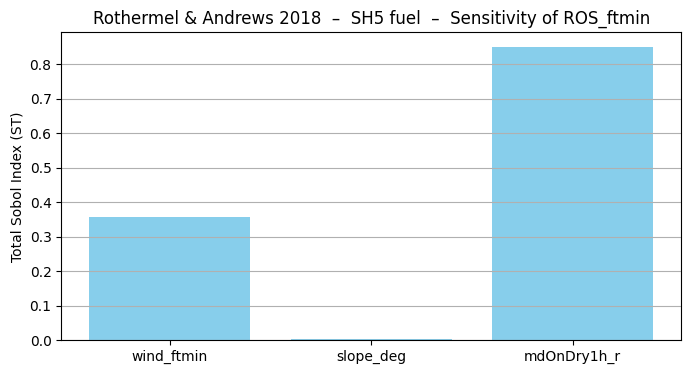

In [5]:

row = (pd.read_csv(io.StringIO(fd.AR2017_table_csv.strip()))
         .query('CODE == "SH5"') # any fuel code here
         .iloc[0]
         .to_dict())
row.update(pd.read_csv(io.StringIO(fd.AR2017_anyfueltable_csv.strip()))
             .iloc[0]
             .to_dict())

Z_base = model_parameters()
Z_base.load(row)

# mandatory attributes not in the table
Z_base.mdOnDry10h_r   = 0.07
Z_base.mdOnDry100h_r  = 0.09
Z_base.mdOnDryLive_r  = 0.80
Z_base.slope_deg      = 0        # will be overwritten by Sobol sample
Z_base.wind_ftmin     = 0        # will be overwritten by Sobol sample
Z_base.mdOnDry1h_r    = 0.05     # will be overwritten by Sobol sample

# -------------------- 3. Define the Sobol problem --------------------
problem = {
    "num_vars": 3,
    "names": ["wind_ftmin", "slope_deg", "mdOnDry1h_r"],
    "bounds": [[0, 1760],          # ft / min  (0–20 mph)
               [0,   30],          # degrees
               [0.01, 0.30]]       # fraction (1–30 %)
}

# -------------------- 4. Generate samples (Saltelli / Sobol) --------------------
param_values = sobol.sample(
    problem,
    N=512,                       # base sample size (total evals = N*(2D+2))
    calc_second_order=False      # speeds things up
)

# -------------------- 5. Evaluate the model --------------------
Y = []

for sample in param_values:
    # ---- build a NEW parameter object each iteration ----
    Z = model_parameters()
    Z.load(row)                  # row already holds all AR-2017 fields

    # fixed attributes (not given in the Sobol space). It's fixed to not contaminate the results.
    Z.mdOnDry10h_r   = 0.07
    Z.mdOnDry100h_r  = 0.09
    Z.mdOnDryLive_r  = 0.80

    # Sobol-sampled inputs. 
    Z.wind_ftmin  = sample[0]
    Z.slope_deg   = sample[1]
    Z.mdOnDry1h_r = sample[2]

    out = RothermelAndrews2018(Z)
    Y.append(out["ROS_ftmin"])


Y = np.array(Y)

# -------------------- 6. Compute Sobol indices --------------------
Si = sobol_analyze.analyze(problem, Y, calc_second_order=False)

print("First-order indices (S1):\n", dict(zip(problem["names"], Si["S1"])))
print("Total-order indices (ST):\n", dict(zip(problem["names"], Si["ST"])))

# -------------------- 7. Plot total-order indices --------------------
plt.figure(figsize=(8,4))
plt.bar(problem["names"], Si["ST"], color="skyblue")
plt.ylabel("Total Sobol Index (ST)")
plt.title("Rothermel & Andrews 2018  –  SH5 fuel  –  Sensitivity of ROS_ftmin")
plt.grid(axis="y")
plt.show()

**The bar graph contains the Total-order indices (ST). These are the variables that are kept constant.**

### Balbi2020

S1: {'wind_mps': 0.5954196234267352, 'slope_deg': 0.030852381110416226, 'mdOnDry1h_r': 0.2629189016515846}
ST: {'wind_mps': 0.6857755185026693, 'slope_deg': 0.03619513864221056, 'mdOnDry1h_r': 0.37422841833531467}


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


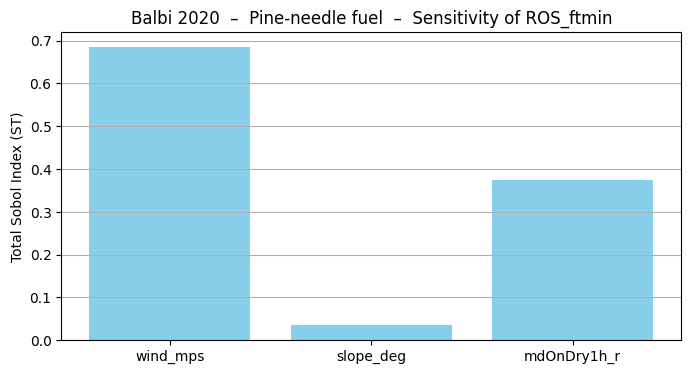

In [6]:
import io, copy, numpy as np, pandas as pd, matplotlib.pyplot as plt
from SALib.sample import sobol
from SALib.analyze import sobol as sob_analyze

from wildfire_ROS_models.model_set import model_parameters
import wildfire_ROS_models.fuels_database as fd
from wildfire_ROS_models.Balbi2020 import Balbi2020

# ---------- 1.  load Balbi pine-needle preset --------------------------------
row = (pd.read_csv(io.StringIO(fd.pineNeedlesBalbi2020_csv.strip()))
         .iloc[0]
         .to_dict())

Z_base = model_parameters()
Z_base.load(row)

# add any environment defaults (will be overwritten by Sobol samples)
Z_base.wind_mps    = 0.     # placeholder
Z_base.slope_deg   = 0.
Z_base.mdOnDry1h_r = 0.05
Z_base.mdOnDry10h_r  = 0.07
Z_base.mdOnDry100h_r = 0.09
Z_base.mdOnDryLive_r = 0.80

# ---------- 2. define Sobol problem ------------------------------------------
problem = {
    "num_vars": 3,
    "names": ["wind_mps", "slope_deg", "mdOnDry1h_r"],
    "bounds": [[0,  9],        # 0–9 m/s  ≈ 0–20 mph
               [0, 30],        # degrees
               [0.01, 0.30]]   # moisture fraction
}

param_values = sobol.sample(problem, N=512, calc_second_order=False)

# ---------- 3. evaluate model -------------------------------------------------
Y = []

for s in param_values:
    Z = model_parameters(); Z.load(row)   # fresh copy each loop
    Z.wind_mps     = s[0]
    Z.slope_deg    = s[1]
    Z.mdOnDry1h_r  = s[2]
    Z.mdOnDry10h_r = 0.07
    Z.mdOnDry100h_r= 0.09
    Z.mdOnDryLive_r= 0.80

    out = Balbi2020(Z)
    Y.append(out["ROS_mps"] * 196.85)     # convert m/s → ft/min for comparability

Y = np.array(Y)

# ---------- 4. Sobol indices --------------------------------------------------
Si = sob_analyze.analyze(problem, Y, calc_second_order=False)
print("S1:", dict(zip(problem["names"], Si["S1"])))
print("ST:", dict(zip(problem["names"], Si["ST"])))

# plot 
plt.figure(figsize=(8,4))
plt.bar(problem["names"], Si["ST"], color="skyblue")
plt.ylabel("Total Sobol Index (ST)")
plt.title("Balbi 2020  –  Pine-needle fuel  –  Sensitivity of ROS_ftmin")
plt.grid(axis="y")
plt.show()


# The following is ONLY RothermelAndrews2018-related content.

## AR2017_table_csv 
1 of 2 given standard fuel sets. Changes slightly each time.

/Users/ethanngo/wildfire_ROS_models/wildfire_ROS_models/RothermelAndrews2018.py:155: RuntimeWarning: invalid value encountered in double_scalars
  WC = (C * wv**B) * math.pow((Beta / Beta_op), (-E))
/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


S₁  : {'wind_ftmin': 0.07214269922205552, 'slope_deg': 0.037671046788211225, 'mdOnDry1h_r': 0.6237509514471079}
ST  : {'wind_ftmin': 0.23005991332261705, 'slope_deg': 0.08780686185742409, 'mdOnDry1h_r': 0.8508655573471546}


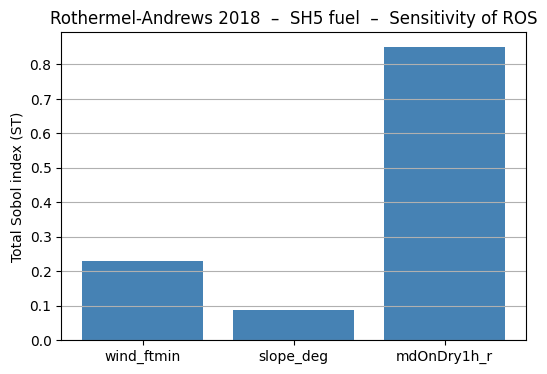

In [9]:
import io, numpy as np, pandas as pd, matplotlib.pyplot as plt
from SALib.sample  import sobol
from SALib.analyze import sobol as sob_analyze

from wildfire_ROS_models.model_set import model_parameters
import wildfire_ROS_models.fuels_database as fd
from wildfire_ROS_models.RothermelAndrews2018 import RothermelAndrews2018

# Load one AR-2017 fuel row (SH5) + shared constants
row = (pd.read_csv(io.StringIO(fd.AR2017_table_csv.strip()))
         .query('CODE == "SH5"').iloc[0].to_dict())
row.update(pd.read_csv(io.StringIO(fd.AR2017_anyfueltable_csv.strip()))
             .iloc[0].to_dict())

# 2-b  Build a baseline parameter object
Z_fuel = model_parameters(); Z_fuel.load(row)
Z_fuel.mdOnDry10h_r   = 0.07
Z_fuel.mdOnDry100h_r  = 0.09
Z_fuel.mdOnDryLive_r  = 0.80

# Define the Sobol problem – only WEATHER variables
problem = {
    "num_vars": 3,
    "names":   ["wind_ftmin", "slope_deg", "mdOnDry1h_r"],
    "bounds":  [[0, 1760],        # wind 0–20 mph (×88 = ft min⁻¹)
                [0, 60],          # slope 0–60 °
                [0.01, 0.30]]     # 1-h moisture 1–30 %
}

param_values = sobol.sample(problem, N=512, calc_second_order=False)

# Run the model for every sample
Y = []
for s in param_values:
    Z = model_parameters(); Z.load(row)          # fixed fuel constants - SAVcar etc.
    Z.mdOnDry10h_r   = 0.07                      # still needed but not varied
    Z.mdOnDry100h_r  = 0.09
    Z.mdOnDryLive_r  = 0.80

    Z.wind_ftmin  = s[0]
    Z.slope_deg   = s[1]
    Z.mdOnDry1h_r = s[2]

    Y.append(RothermelAndrews2018(Z)["ROS_ftmin"])

Y = np.asarray(Y)

# Compute and plot Sobol indices
Si = sob_analyze.analyze(problem, Y, calc_second_order=False)
print("S₁  :", dict(zip(problem["names"], Si["S1"])))
print("ST  :", dict(zip(problem["names"], Si["ST"])))

plt.figure(figsize=(6,4))
plt.bar(problem["names"], Si["ST"], color="steelblue")
plt.ylabel("Total Sobol index (ST)")
plt.title("Rothermel-Andrews 2018  –  SH5 fuel  –  Sensitivity of ROS")
plt.grid(axis="y")
plt.show()


**The values are from ST.**

# CB2005_t7_csv

### meant for Rothermel-1972 (an older version model), but can be used in 2018 model

Total model evaluations: 2560
S₁ : {'wind_ftmin': 0.4619737237860243, 'slope_deg': 0.12083047534053039, 'mdOnDry1h_r': 0.30510383267647945}
ST : {'wind_ftmin': 0.5611080699648946, 'slope_deg': 0.1313193970460059, 'mdOnDry1h_r': 0.4225750668734257}


/opt/anaconda3/envs/tf-env/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


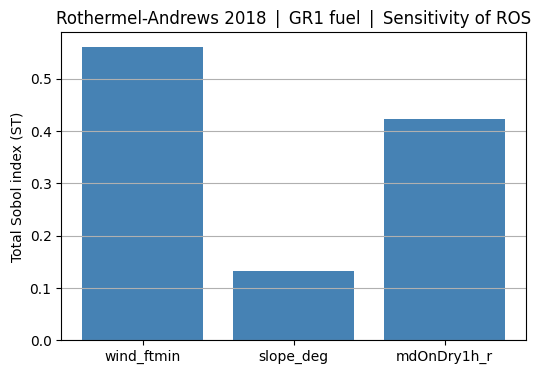

In [12]:
import io, numpy as np, pandas as pd, matplotlib.pyplot as plt
from SALib.sample  import sobol
from SALib.analyze import sobol as sob_analyze

from wildfire_ROS_models.model_set import model_parameters
import wildfire_ROS_models.fuels_database as fd
from wildfire_ROS_models.RothermelAndrews2018 import RothermelAndrews2018

# Load a CB-2005 fuel row (e.g. GR1) -------------------------------
row = (pd.read_csv(io.StringIO(fd.CB2005_t7_csv.strip()))
         .query('CODE == "GS4"') # can change to other fuel codes from CB2005_t7_csv
         .iloc[0]
         .to_dict())

# Add the extra attributes Andrews-2018 expects 
# You can pick representative values from a similar AR-2017 row
row.update({
    "SAVcar_ftinv"   : 2000,   # typical fine-fuel SAV (ft⁻¹)
    "bulkDens_lbft3" : 32,     # oven-dry particle density
    "packRatio_r"    : 0.08    # packing ratio (bulk / particle dens.)
})

# Build a baseline parameter object
Z0 = model_parameters(); Z0.load(row)

# add moisture defaults
Z0.mdOnDry10h_r   = 0.07
Z0.mdOnDry100h_r  = 0.09
Z0.mdOnDryLive_r  = 0.80
Z0.wind_ftmin     = 880     # placeholder 10 mph
Z0.slope_deg      = 5
Z0.mdOnDry1h_r    = 0.05

# Sobol problem – vary only weather inputs -------------------------
problem = {
    "num_vars": 3,
    "names"  : ["wind_ftmin", "slope_deg", "mdOnDry1h_r"],
    "bounds" : [[0, 1760],     # 0–20 mph  (ft min⁻¹)
                [0,   60],     # slope 0–60°
                [0.01, 0.30]]  # 1-h fuel-moisture fraction
}

param_values = sobol.sample(problem, N=512, calc_second_order=False)
print("Total model evaluations:", len(param_values))

row.update({
    # required for Rothermel & Andrews 2018 
    "fuelDens_lbft3": 32,              # particle density
    "bulkDens_lbft3": 2.5,             # choose 2–3 for grass, 6–8 for litter
    "packRatio_r"   : 2.5/32,          # bulk / particle
    "totMineral_r"  : 0.055,           # 5.5 %
    "effectMineral_r": 0.010           # 1 %
})


# Evaluate the model 
Y = []
for s in param_values:
    Z = model_parameters(); Z.load(row) # fixed fuel constants
    Z.mdOnDry10h_r   = 0.07
    Z.mdOnDry100h_r  = 0.09
    Z.mdOnDryLive_r  = 0.80

    Z.wind_ftmin  = s[0]
    Z.slope_deg   = s[1]
    Z.mdOnDry1h_r = s[2]

    Y.append(RothermelAndrews2018(Z)["ROS_ftmin"])

Y = np.asarray(Y)

# Sobol indices 
Si = sob_analyze.analyze(problem, Y, calc_second_order=False)
print("S₁ :", dict(zip(problem["names"], Si["S1"])))
print("ST :", dict(zip(problem["names"], Si["ST"])))

# Plot 
plt.figure(figsize=(6,4))
plt.bar(problem["names"], Si["ST"], color="steelblue")
plt.ylabel("Total Sobol index (ST)")
plt.title("Rothermel-Andrews 2018 | GR1 fuel | Sensitivity of ROS")
plt.grid(axis="y")
plt.show()

## ROS for each Fuel Code, Given User-Adjustable Variables right below

In [14]:
WIND_MPH       = 10          # mid-flame wind (mph)
SLOPE_DEG      = 0.00           # terrain slope (degrees)
MOIST_1H       = 0.05        # 5 % dead fine-fuel moisture (fraction)

[warning] TL5 not in CB2005_t7_csv; skipping.


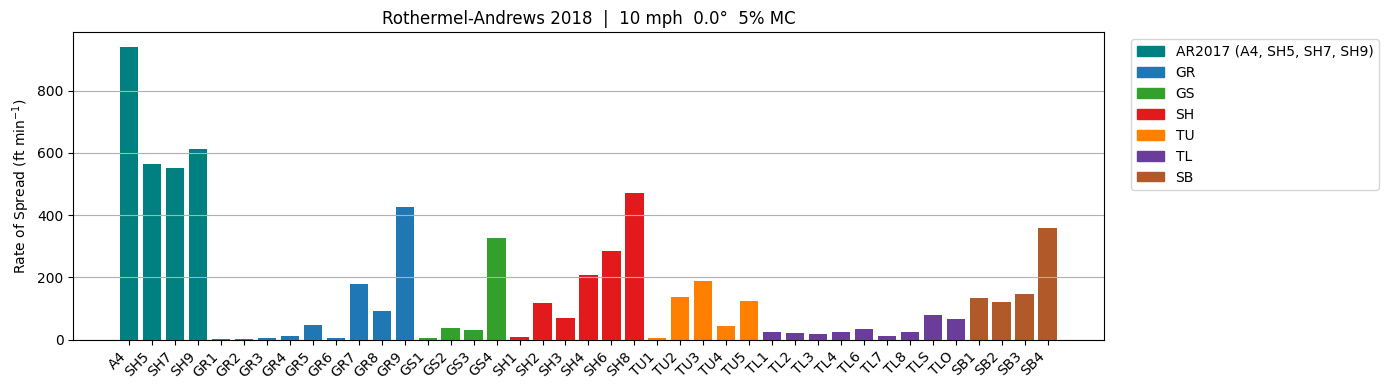

In [16]:
import io, numpy as np, pandas as pd, matplotlib.pyplot as plt
from wildfire_ROS_models.model_set import model_parameters
import wildfire_ROS_models.fuels_database as fd
from wildfire_ROS_models.RothermelAndrews2018 import RothermelAndrews2018

# a list of fuel codes 
ar_codes = ["A4", "SH5", "SH7", "SH9"]
cb_codes = (
    [f"GR{i}" for i in range(1,10)] +      # GR1 … GR9  (Grass)
    [f"GS{i}" for i in range(1,5)]  +      # GS1 … GS4  (Grass-Shrub)
    [f"SH{i}" for i in range(1,10)] +      # SH1 … SH9  (Shrub)
    [f"TU{i}" for i in range(1,6)]  +      # TU1 … TU5  (Timber-Understory)
    [f"TL{i}" for i in range(1,9)]  +      # TL1 … TL8  (Timber Litter)
    ["TLS", "TLO"] +                       # two extra litter models
    [f"SB{i}" for i in range(1,5)]         # SB1 … SB4  (Slash / Blow-down)
)

cb_codes = [c for c in cb_codes if c not in set(ar_codes)]

fuel_codes = ar_codes + cb_codes        # master list

ros_vals = []     # to store Rate-of-Spread
labels   = []     # x-tick labels

# Helper – return a fully-populated row dict 
def get_row(code):
    if code in {"A4","SH5","SH7","SH9"}:              # AR-2017
        row = (pd.read_csv(io.StringIO(fd.AR2017_table_csv.strip()))
                 .query(f'CODE == "{code}"').iloc[0].to_dict())
        row.update(pd.read_csv(io.StringIO(fd.AR2017_anyfueltable_csv.strip()))
                     .iloc[0].to_dict())
    else:                                     # CB-2005 branch
        df = pd.read_csv(io.StringIO(fd.CB2005_t7_csv.strip()))
        rowdf = df.query(f'CODE == "{code}"')
        if rowdf.empty:                       # → code not found
            print(f"[warning] {code} not in CB2005_t7_csv; skipping.")
            return None
        row = rowdf.iloc[0].to_dict()
        # add the three constants Andrews-2018 needs
        row.update({"SAVcar_ftinv": 1500,          # choose a plausible median
                    "fuelDens_lbft3": 32,
                    "bulkDens_lbft3": 2.5,
                    "packRatio_r":    2.5/32})
        # mineral defaults
        row.update({"totMineral_r": 0.055, "effectMineral_r": 0.010})
    return row

# Loop through fuels 
for code in fuel_codes:
    row = get_row(code)
    if row is None:
        continue
    Z = model_parameters(); Z.load(row)

    # set environment
    Z.wind_ftmin  = WIND_MPH * 88
    Z.slope_deg   = SLOPE_DEG
    Z.mdOnDry1h_r = MOIST_1H
    Z.mdOnDry10h_r = 0.07
    Z.mdOnDry100h_r= 0.09
    Z.mdOnDryLive_r= 0.80

    ros = RothermelAndrews2018(Z)["ROS_ftmin"]
    labels.append(code)
    ros_vals.append(ros)

# Plot 
# ---------------------------------------------------------------
# Color palette (AR group gets its own color)
palette = {
    "AR": "#008080",   # teal  <- applies to ALL ar_codes
    "GR": "#1f78b4",
    "GS": "#33a02c",
    "SH": "#e31a1c",
    "TU": "#ff7f00",
    "TL": "#6a3d9a",
    "SB": "#b15928"
}

def bar_color(code):
    if code in ar_codes:
        return palette["AR"]
    return palette.get(code[:2], "#999999")  # fallback grey

# Build rows, run model, collect ROS (same as before) 


bar_colors = [bar_color(c) for c in labels]

# plot
plt.figure(figsize=(14,4))
plt.bar(labels, ros_vals, color=bar_colors)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Rate of Spread (ft min$^{-1}$)")
plt.title(f"Rothermel-Andrews 2018  |  {WIND_MPH} mph  {SLOPE_DEG}°  {MOIST_1H*100:.0f}% MC")
plt.grid(axis="y")

# legend: AR group + each CB family present
from matplotlib.patches import Patch
legend_handles = [Patch(color=palette["AR"], label="AR2017 (A4, SH5, SH7, SH9)")]
for pref in ("GR","GS","SH","TU","TL","SB"):
    if any(code.startswith(pref) for code in cb_codes):
        legend_handles.append(Patch(color=palette[pref], label=pref))
plt.legend(handles=legend_handles, bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

# Plotting Wind to ROS

### CB2005_t7_csv

SH5 | wind: 10 mph → 880 ft/min | slope: 10°
ROS at 10 mph: 688.5134308988265


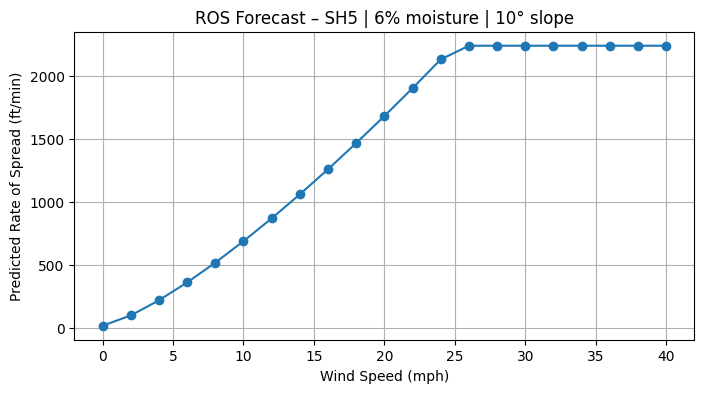

In [19]:
FUEL_CODE   = "SH5"         # adjustable fuel type
SLOPE_DEG   = 10            # Moderate slope
MOIST_1H    = 0.06          # Fine dead fuel moisture
MOIST_10H   = 0.07
MOIST_100H  = 0.09
MOIST_LIVE  = 0.80


# Load selected fuel from CB2005_t7_csv
df = pd.read_csv(io.StringIO(fd.CB2005_t7_csv.strip()))
rowdf = df.query(f'CODE == "{FUEL_CODE}"')

if rowdf.empty:
    raise ValueError(f"Fuel code {FUEL_CODE} not found in CB2005_t7_csv")

row = rowdf.iloc[0].to_dict()

# Add necessary constants for RothermelAndrews2018
row.update({
    "SAVcar_ftinv": 1500,            # typical value
    "fuelDens_lbft3": 32,
    "bulkDens_lbft3": 2.5,
    "packRatio_r": 2.5 / 32,
    "totMineral_r": 0.055,
    "effectMineral_r": 0.010
})

# Wind test range
wind_mph_range = np.arange(0, 41, 2)  # 0 to 40 mph
ros_vals = []

for mph in wind_mph_range:
    Z = model_parameters()
    Z.load(row)
    Z.wind_ftmin      = mph * 88      # convert mph → ft/min
    Z.slope_deg       = SLOPE_DEG
    Z.mdOnDry1h_r     = MOIST_1H
    Z.mdOnDry10h_r    = MOIST_10H
    Z.mdOnDry100h_r   = MOIST_100H
    Z.mdOnDryLive_r   = MOIST_LIVE

    ros = RothermelAndrews2018(Z)["ROS_ftmin"]
    ros_vals.append(ros)

# print sanity-check values
print(f"{FUEL_CODE} | wind: 10 mph → 880 ft/min | slope: {SLOPE_DEG}°")
print("ROS at 10 mph:", ros_vals[5])  # Index 5 → 10 mph

# Plot
plt.figure(figsize=(8,4))
plt.plot(wind_mph_range, ros_vals, marker="o", linestyle="-")
plt.xlabel("Wind Speed (mph)")
plt.ylabel("Predicted Rate of Spread (ft/min)")
plt.title(f"ROS Forecast – {FUEL_CODE} | {MOIST_1H*100:.0f}% moisture | {SLOPE_DEG}° slope")
plt.grid(True)
plt.show()

## Plotting Multiple Fuels of Wind to ROS

### CB2005_t7_csv dataset

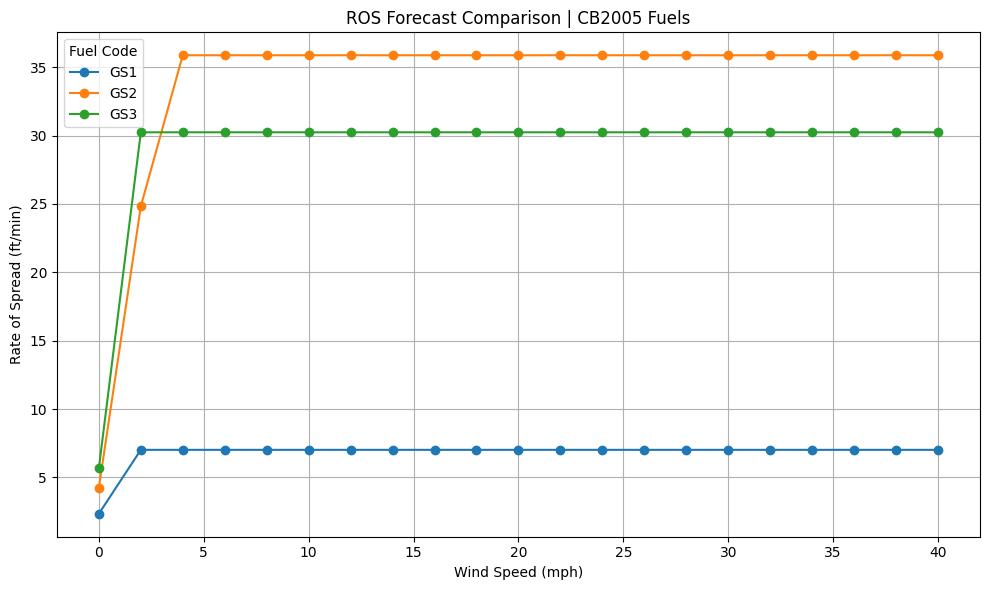

In [20]:
# Environmental settings (adjustable)
SLOPE_DEG   = 10 # adjustable
MOIST_1H    = 0.06 #...
MOIST_10H   = 0.07
MOIST_100H  = 0.09
MOIST_LIVE  = 0.80

# Fuel codes to compare
fuel_codes = ["GS1","GS2","GS3"]
# Wind speeds to test
wind_mph_range = np.arange(0, 41, 2)

# Plot
plt.figure(figsize=(10, 6))

for code in fuel_codes:
    # Load fuel parameters
    df = pd.read_csv(io.StringIO(fd.CB2005_t7_csv.strip()))
    rowdf = df.query(f'CODE == "{code}"')
    if rowdf.empty:
        print(f"⚠️ Skipping {code} (not found)")
        continue
    row = rowdf.iloc[0].to_dict()
    row.update({
        "SAVcar_ftinv": 1500,
        "fuelDens_lbft3": 32,
        "bulkDens_lbft3": 2.5,
        "packRatio_r": 2.5 / 32,
        "totMineral_r": 0.055,
        "effectMineral_r": 0.010
    })

    ros_vals = []
    for mph in wind_mph_range:
        Z = model_parameters()
        Z.load(row)
        Z.wind_ftmin = mph * 88
        Z.slope_deg = SLOPE_DEG
        Z.mdOnDry1h_r = MOIST_1H
        Z.mdOnDry10h_r = MOIST_10H
        Z.mdOnDry100h_r = MOIST_100H
        Z.mdOnDryLive_r = MOIST_LIVE

        ros = RothermelAndrews2018(Z)["ROS_ftmin"]
        ros_vals.append(ros)

    plt.plot(wind_mph_range, ros_vals, marker="o", label=code)

# plot
plt.xlabel("Wind Speed (mph)")
plt.ylabel("Rate of Spread (ft/min)")
plt.title("ROS Forecast Comparison | CB2005 Fuels")
plt.grid(True)
plt.legend(title="Fuel Code")
plt.tight_layout()
plt.show()

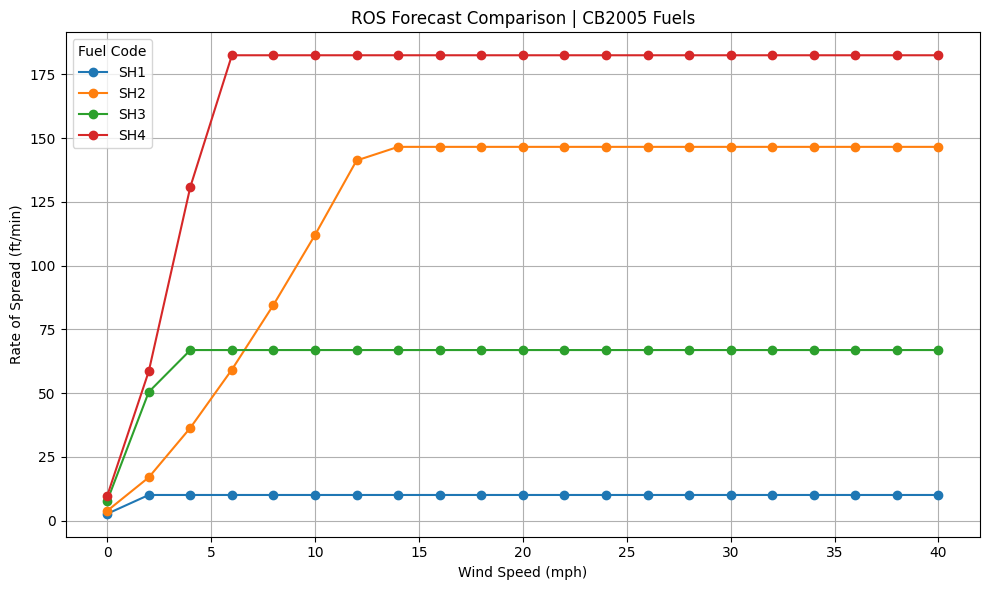

In [68]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from wildfire_ROS_models.model_set import model_parameters
import wildfire_ROS_models.fuels_database as fd
from wildfire_ROS_models.RothermelAndrews2018 import RothermelAndrews2018
import io

# Environmental settings
SLOPE_DEG   = 10
MOIST_1H    = 0.06
MOIST_10H   = 0.07
MOIST_100H  = 0.09
MOIST_LIVE  = 0.80

# Fuel codes to compare
fuel_codes = ["SH1","SH2","SH3","SH4"]
# [,"SH5","SH6","SH7","SH8","SH9"]

# Wind speeds to test
wind_mph_range = np.arange(0, 41, 2)

# Plot
plt.figure(figsize=(10, 6))

for code in fuel_codes:
    # Load fuel parameters
    df = pd.read_csv(io.StringIO(fd.CB2005_t7_csv.strip()))
    rowdf = df.query(f'CODE == "{code}"')
    if rowdf.empty:
        print(f"⚠️ Skipping {code} (not found)")
        continue
    row = rowdf.iloc[0].to_dict()
    row.update({
        "SAVcar_ftinv": 1500,
        "fuelDens_lbft3": 32,
        "bulkDens_lbft3": 2.5,
        "packRatio_r": 2.5 / 32,
        "totMineral_r": 0.055,
        "effectMineral_r": 0.010
    })

    ros_vals = []
    for mph in wind_mph_range:
        Z = model_parameters()
        Z.load(row)
        Z.wind_ftmin = mph * 88
        Z.slope_deg = SLOPE_DEG
        Z.mdOnDry1h_r = MOIST_1H
        Z.mdOnDry10h_r = MOIST_10H
        Z.mdOnDry100h_r = MOIST_100H
        Z.mdOnDryLive_r = MOIST_LIVE

        ros = RothermelAndrews2018(Z)["ROS_ftmin"]
        ros_vals.append(ros)

    plt.plot(wind_mph_range, ros_vals, marker="o", label=code)

# Final plot formatting
plt.xlabel("Wind Speed (mph)")
plt.ylabel("Rate of Spread (ft/min)")
plt.title("ROS Forecast Comparison | CB2005 Fuels")
plt.grid(True)
plt.legend(title="Fuel Code")
plt.tight_layout()
plt.show()


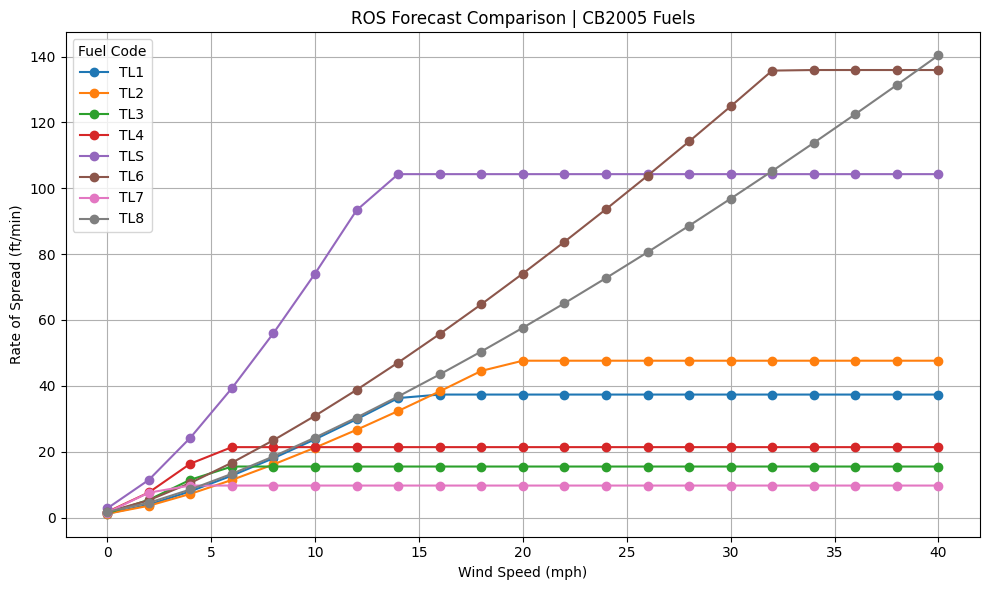

In [71]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from wildfire_ROS_models.model_set import model_parameters
import wildfire_ROS_models.fuels_database as fd
from wildfire_ROS_models.RothermelAndrews2018 import RothermelAndrews2018
import io

# Environmental settings
SLOPE_DEG   = 10
MOIST_1H    = 0.06
MOIST_10H   = 0.07
MOIST_100H  = 0.09
MOIST_LIVE  = 0.80

# Fuel codes to compare
fuel_codes = ["TL1", 'TL2', 'TL3', 'TL4', 'TLS', 'TL6', 'TL7', 'TL8']

# Wind speeds to test
wind_mph_range = np.arange(0, 41, 2)

# Plot
plt.figure(figsize=(10, 6))

for code in fuel_codes:
    # Load fuel parameters
    df = pd.read_csv(io.StringIO(fd.CB2005_t7_csv.strip()))
    rowdf = df.query(f'CODE == "{code}"')
    if rowdf.empty:
        print(f"⚠️ Skipping {code} (not found)")
        continue
    row = rowdf.iloc[0].to_dict()
    row.update({
        "SAVcar_ftinv": 1500,
        "fuelDens_lbft3": 32,
        "bulkDens_lbft3": 2.5,
        "packRatio_r": 2.5 / 32,
        "totMineral_r": 0.055,
        "effectMineral_r": 0.010
    })

    ros_vals = []
    for mph in wind_mph_range:
        Z = model_parameters()
        Z.load(row)
        Z.wind_ftmin = mph * 88
        Z.slope_deg = SLOPE_DEG
        Z.mdOnDry1h_r = MOIST_1H
        Z.mdOnDry10h_r = MOIST_10H
        Z.mdOnDry100h_r = MOIST_100H
        Z.mdOnDryLive_r = MOIST_LIVE

        ros = RothermelAndrews2018(Z)["ROS_ftmin"]
        ros_vals.append(ros)

    plt.plot(wind_mph_range, ros_vals, marker="o", label=code)

# Final plot formatting
plt.xlabel("Wind Speed (mph)")
plt.ylabel("Rate of Spread (ft/min)")
plt.title("ROS Forecast Comparison | CB2005 Fuels")
plt.grid(True)
plt.legend(title="Fuel Code")
plt.tight_layout()
plt.show()


### AR2017_table_csv dataset

The plot has a stsaggeringly high ROS, which is unrealistic. This implies that these few values from AR2017_table_csv are for extreme fire behavior, like explosive shrubland or other "worst-case" fuels.

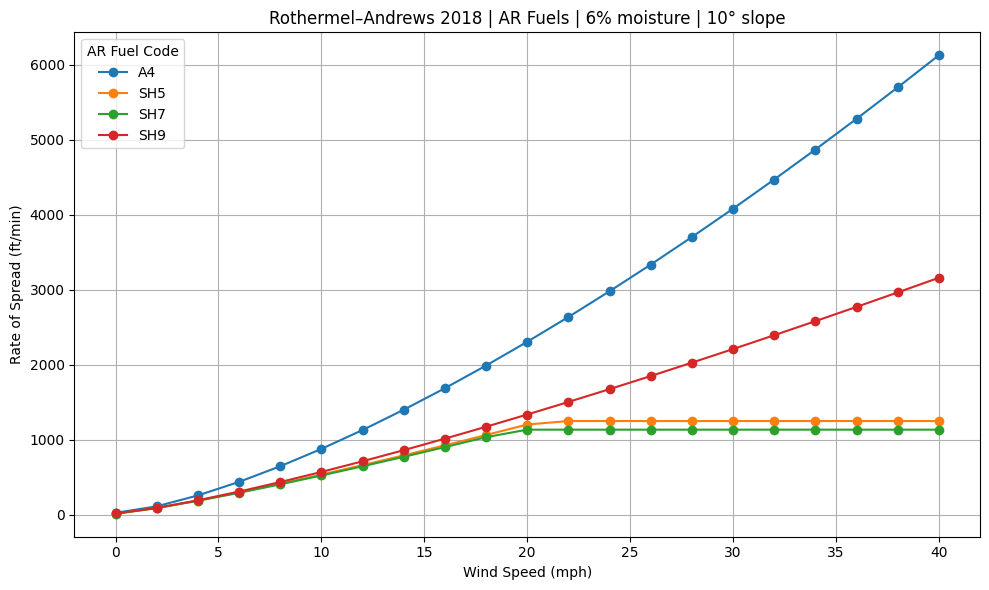

In [21]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from wildfire_ROS_models.model_set import model_parameters
import wildfire_ROS_models.fuels_database as fd
from wildfire_ROS_models.RothermelAndrews2018 import RothermelAndrews2018
import io

# Environmental inputs
SLOPE_DEG   = 10
MOIST_1H    = 0.06
MOIST_10H   = 0.07
MOIST_100H  = 0.09
MOIST_LIVE  = 0.80

# AR-standard fuels
fuel_codes = ["A4", "SH5", "SH7", "SH9"]
wind_mph_range = np.arange(0, 41, 2)  # 0 to 40 mph

# Plot setup
plt.figure(figsize=(10, 6))

for code in fuel_codes:
    # Load AR fuel row
    row = (pd.read_csv(io.StringIO(fd.AR2017_table_csv.strip()))
             .query(f'CODE == "{code}"').iloc[0].to_dict())
    row.update(pd.read_csv(io.StringIO(fd.AR2017_anyfueltable_csv.strip()))
                 .iloc[0].to_dict())

    ros_vals = []
    for mph in wind_mph_range:
        Z = model_parameters()
        Z.load(row)
        Z.wind_ftmin      = mph * 88
        Z.slope_deg       = SLOPE_DEG
        Z.mdOnDry1h_r     = MOIST_1H
        Z.mdOnDry10h_r    = MOIST_10H
        Z.mdOnDry100h_r   = MOIST_100H
        Z.mdOnDryLive_r   = MOIST_LIVE

        ros = RothermelAndrews2018(Z)["ROS_ftmin"]
        ros_vals.append(ros)

    plt.plot(wind_mph_range, ros_vals, marker="o", label=code)

# Final formatting
plt.xlabel("Wind Speed (mph)")
plt.ylabel("Rate of Spread (ft/min)")
plt.title(f"Rothermel–Andrews 2018 | AR Fuels | {MOIST_1H*100:.0f}% moisture | {SLOPE_DEG}° slope")
plt.grid(True)
plt.legend(title="AR Fuel Code")
plt.tight_layout()
plt.show()


# **ignore the rest below**

### Validation, Accuracy, RSME, etc.

### Loading the Outside Dataset

In [3]:
'''import geopandas as gpd
import os

# 1) Point to the .shp (replace with your actual filename)

folder = "/Users/ethanngo/Desktop/S_USA.Fire_FPA_FOD_6th_Fires"

for f in os.listdir(folder):
    if f.lower().endswith(".shp"):
        shp_path = os.path.join(folder, f)
        break
print("Using: ", shp_path)
    


# 2) Read it
gdf = gpd.read_file(shp_path)
print("Rows:", len(gdf))
print("Columns:", gdf.columns.tolist())

# 3) Peek at the first few fires
gdf.head()'''

'import geopandas as gpd\nimport os\n\n# 1) Point to the .shp (replace with your actual filename)\n\nfolder = "/Users/ethanngo/Desktop/S_USA.Fire_FPA_FOD_6th_Fires"\n\nfor f in os.listdir(folder):\n    if f.lower().endswith(".shp"):\n        shp_path = os.path.join(folder, f)\n        break\nprint("Using: ", shp_path)\n    \n\n\n# 2) Read it\ngdf = gpd.read_file(shp_path)\nprint("Rows:", len(gdf))\nprint("Columns:", gdf.columns.tolist())\n\n# 3) Peek at the first few fires\ngdf.head()'

In [4]:
'''import pandas as pd
from datetime import datetime, timedelta

def julian_to_dt(year, julian, hhmm):
    """
    Convert year + Julian-day (float) + hhmm int/str → datetime.
    If 'julian' is already a Timestamp/Datetime, return it unchanged.
    """
    # Case 1: already datetime
    if isinstance(julian, (pd.Timestamp, datetime)):
        return julian.to_pydatetime()

    # Case 2: Julian day number
    doy_int = int(julian)
    secs = (julian - doy_int) * 86400
    base = datetime(year, 1, 1) + timedelta(days=doy_int - 1, seconds=secs)

    # Optional hhmm (may be NaN or Timestamp)
    if pd.notna(hhmm):
        hhmm = int(hhmm)
        hour, minute = divmod(hhmm, 100)
        base = base.replace(hour=hour, minute=minute)
    return base

# ---- build the new datetime columns safely ----
gdf["disc_dt"] = gdf.apply(
    lambda r: julian_to_dt(r.FIRE_YEAR, r.DISCOVERY_, r.DISCOVER_1), axis=1)

gdf["cont_dt"] = gdf.apply(
    lambda r: julian_to_dt(r.FIRE_YEAR, r.CONT_DATE, r.CONT_TIME), axis=1)
'''

'import pandas as pd\nfrom datetime import datetime, timedelta\n\ndef julian_to_dt(year, julian, hhmm):\n    """\n    Convert year + Julian-day (float) + hhmm int/str → datetime.\n    If \'julian\' is already a Timestamp/Datetime, return it unchanged.\n    """\n    # Case 1: already datetime\n    if isinstance(julian, (pd.Timestamp, datetime)):\n        return julian.to_pydatetime()\n\n    # Case 2: Julian day number\n    doy_int = int(julian)\n    secs = (julian - doy_int) * 86400\n    base = datetime(year, 1, 1) + timedelta(days=doy_int - 1, seconds=secs)\n\n    # Optional hhmm (may be NaN or Timestamp)\n    if pd.notna(hhmm):\n        hhmm = int(hhmm)\n        hour, minute = divmod(hhmm, 100)\n        base = base.replace(hour=hour, minute=minute)\n    return base\n\n# ---- build the new datetime columns safely ----\ngdf["disc_dt"] = gdf.apply(\n    lambda r: julian_to_dt(r.FIRE_YEAR, r.DISCOVERY_, r.DISCOVER_1), axis=1)\n\ngdf["cont_dt"] = gdf.apply(\n    lambda r: julian_to_dt(r.FI

In [5]:
'''# duration in minutes
gdf["duration_min"] = (gdf.cont_dt - gdf.disc_dt).dt.total_seconds() / 60
gdf = gdf[(gdf.duration_min > 0)]              # drop bad rows

# approximate linear distance = sqrt(area)  (acres → feet)
ACRE_TO_SQFT = 43560
gdf["radius_ft"] = np.sqrt(gdf.FIRE_SIZE * ACRE_TO_SQFT / np.pi)
gdf["ROS_ftmin_obs"] = gdf.radius_ft / gdf.duration_min


# look at the first few rows
gdf[["FIRE_NAME", "duration_min", "radius_ft", "ROS_ftmin_obs"]].head()
'''

'# duration in minutes\ngdf["duration_min"] = (gdf.cont_dt - gdf.disc_dt).dt.total_seconds() / 60\ngdf = gdf[(gdf.duration_min > 0)]              # drop bad rows\n\n# approximate linear distance = sqrt(area)  (acres → feet)\nACRE_TO_SQFT = 43560\ngdf["radius_ft"] = np.sqrt(gdf.FIRE_SIZE * ACRE_TO_SQFT / np.pi)\ngdf["ROS_ftmin_obs"] = gdf.radius_ft / gdf.duration_min\n\n\n# look at the first few rows\ngdf[["FIRE_NAME", "duration_min", "radius_ft", "ROS_ftmin_obs"]].head()\n'

In [6]:
'''# ───────────────────────────────────────────────────────────────────────
# STEP 5 · Predict ROS for every fire
# ───────────────────────────────────────────────────────────────────────
from wildfire_ROS_models.model_set import model_parameters
from wildfire_ROS_models.RothermelAndrews2018 import RothermelAndrews2018
# from wildfire_ROS_models.Balbi2020 import Balbi2020   # swap if needed

def env_inputs(row):
    """Return wind_mph, slope_deg, moisture for this fire.
       Replace with real weather/topo joins later."""
    return 10.0, 0.0, 0.06           # <-- placeholder constants

def predict_ros(row):
    wind_mph, slope_deg, moist = env_inputs(row)
    Z = model_parameters()
    Z.wind_ftmin   = wind_mph * 88
    Z.slope_deg    = slope_deg
    Z.mdOnDry1h_r  = moist

    # required static fuel constants (tweak as needed)
    Z.SAVcar_ftinv   = 1500
    Z.fuelDens_lbft3 = 32
    Z.bulkDens_lbft3 = 2.5
    Z.packRatio_r    = 2.5 / 32
    Z.totMineral_r   = 0.055
    Z.effectMineral_r = 0.010

    return RothermelAndrews2018(Z)["ROS_ftmin"]

gdf["ROS_ftmin_pred"] = gdf.apply(predict_ros, axis=1)

# ───────────────────────────────────────────────────────────────────────
# STEP 6 · Accuracy metrics
# ───────────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
obs  = gdf["ROS_ftmin_obs"]
pred = gdf["ROS_ftmin_pred"]

rmse = mean_squared_error(obs, pred, squared=False)
mae  = mean_absolute_error(obs, pred)
bias = (pred - obs).mean()
r2   = r2_score(obs, pred)

print(f"RMSE : {rmse:6.2f} ft/min")
print(f"MAE  : {mae:6.2f} ft/min")
print(f"Bias : {bias:6.2f} ft/min  (positive = model high)")
print(f"R²   : {r2:6.2f}")

# ───────────────────────────────────────────────────────────────────────
# STEP 7 · Predicted vs Observed scatter
# ───────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(obs, pred, alpha=0.6, color="#1f78b4")
plt.plot([0, obs.max()], [0, obs.max()], "--", color="gray")
plt.xlabel("Observed ROS (ft min$^{-1}$)")
plt.ylabel("Predicted ROS (ft min$^{-1}$)")
plt.title("Rothermel–Andrews 2018: Model vs FPA-FOD observations")
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()
'''

'# ───────────────────────────────────────────────────────────────────────\n# STEP 5 · Predict ROS for every fire\n# ───────────────────────────────────────────────────────────────────────\nfrom wildfire_ROS_models.model_set import model_parameters\nfrom wildfire_ROS_models.RothermelAndrews2018 import RothermelAndrews2018\n# from wildfire_ROS_models.Balbi2020 import Balbi2020   # swap if needed\n\ndef env_inputs(row):\n    """Return wind_mph, slope_deg, moisture for this fire.\n       Replace with real weather/topo joins later."""\n    return 10.0, 0.0, 0.06           # <-- placeholder constants\n\ndef predict_ros(row):\n    wind_mph, slope_deg, moist = env_inputs(row)\n    Z = model_parameters()\n    Z.wind_ftmin   = wind_mph * 88\n    Z.slope_deg    = slope_deg\n    Z.mdOnDry1h_r  = moist\n\n    # required static fuel constants (tweak as needed)\n    Z.SAVcar_ftinv   = 1500\n    Z.fuelDens_lbft3 = 32\n    Z.bulkDens_lbft3 = 2.5\n    Z.packRatio_r    = 2.5 / 32\n    Z.totMineral_r   =